The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
data length =  2400
primes =  [ 2  3  5  7 11 13 17 19]
base freq =  0.05
IX =  [ 4  6 10 14 22 26 34 38]
freqs =  [0.1  0.15 0.25 0.35 0.55 0.65 0.85 0.95]
omegas =  [0.62831853 0.9424778  1.57079633 2.19911486 3.45575192 4.08407045
 5.34070751 5.96902604]
T =  40
t =  [0.00000000e+00 1.66736140e-02 3.33472280e-02 ... 3.99666528e+01
 3.99833264e+01 4.00000000e+01]
fs =  60
sample_period (dt)=  0.016666666666666666
xf =  [0.0000e+00 2.5000e-02 5.0000e-02 ... 2.9925e+01 2.9950e+01 2.9975e+01]
s =  <function <lambda> at 0x13e285e40>
z =  <function <lambda> at 0x13e658400>
soM =  [ 0.71461011-0.8032687j   0.33652234-0.98372476j -0.33237591-0.86073923j
 -0.6163471 -0.48027949j -0.55477368+0.01684599j -0.46273241+0.11912274j
 -0.31404983+0.19698778j -0.26054454+0.2069847j ]
zero =  <function zero at 0x13e658540>
first =  <function first at 0x13e99e700>
second =  <function second at 0x13e99f1a0>
subject_n

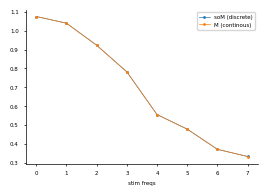

(11, 3, 21, 8)
(11, 3, 21, 8)
(11, 3, 21, 8)
(11, 12, 8)
(11, 12, 8)
(11, 12, 8)


In [136]:
# auto reload modules
%load_ext autoreload
%autoreload 2


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D
import copy as copy
import time as tpy
import pandas as pd
from scipy import stats,signal, fft
from scipy.stats import norm,wilcoxon
import sys, os
import sys
import figurefirst as fifi
from IPython.display import display,SVG
from globalVars import *
from load_data import *
from analysis import mean_and_interquartile,WilcoxonTest
from collect_data import findFilename, getrawdata, get_data, analyze
import plotting_variables
from plotting_variables import MINI_SIZE, TINY_SIZE, SMALL_SIZE, MEDIUM_SIZE, BIGGER_SIZE, MARKER_SIZE, python_colors, colors, yfill, ufill, gfill, rfill, bfill
from matplotlib.colors import to_rgba
from matplotlib.transforms import blended_transform_factory

print('data length = ',N)
print('primes = ',primes)
print('base freq = ',base_freq)
print('IX = ',IX)
print('freqs = ',freqs)
print('omegas = ',omegas)
print('T = ',T) # total time 40 seconds
print('t = ',t) # timestamps
print('fs = ',fs)
print('sample_period (dt)= ',dt)
print('xf = ',xf) # frequency domain x-axis, shape (N//2,)
print('s = ',s)
print('z = ',z)
print('soM = ',soM)
print('zero = ',zero)
print('first = ',first)
print('second = ',second)

print('subject_num = ',subject_num)
print('condition_num (orders) = ',condition_num)
print('trial_num = ',trial_num)
print('trial_num of baseline = ',trial_num_base)
print('\n')

# interface transfer function parameters (subjects x trials x number of parameters)
print('0th-order interface parameters, G_parameters shape= ',G_parameters[0].shape)
print('1st-order interface parameters, G_parameters shape= ',G_parameters[1].shape)
print('2nd-order interface parameters, G_parameters shape= ',G_parameters[2].shape)
# print(G_parameters[0].shape,G_parameters[1].shape,G_parameters[2].shape) 
print('\n')

# freqeuncy domain signals
print('Interface transfer function, Gs shape=', Gs.shape) # interface transfer function (subjects x condition x trials x stim frequencies)
print('Human transfer function, Hs shape=',Hs.shape) # human transfer function (subjects x condition x trials x stim frequencies)
print('Disturbance signals, Ds shape=', Ds.shape) # disturbances (subjects x condition x trials x number of frequencies)
print('Human inputs signals, UHs shape=', UHs.shape) # human inputs (subjects x condition x trials x number of frequencies)
print('Interface inputs signals, UIs shape=', UGs.shape) # interface inputs (subjects x condition x trials x number of frequencies)
print('Output signals, Ys shape=', Ys.shape) # output (subjects x condition x trials x number of frequencies)
print('\n')
print('Baseline interface transfer function, Gs_base shape=', Gs_base.shape) # interface transfer function (subjects x trials x stim frequencies)
print('\n')

# time domain signals
print('time-domain disturbances, ds shape=', ds.shape) # disturbances (subjects x condition x trials x number of time points)
print('time-domain human inputs, uhs shape=', uhs.shape) # human inputs (subjects x condition x trials x number of time points)
print('time-domain interface inputs, ugs shape=', ugs.shape) # interface inputs (subjects x condition x trials x number of time points)
print('time-domain outputs, ys shape=', ys.shape) # output (subjects x condition x trials x number of time points)
print('time-domain MSE per trial, errors shape=',errors.shape) # errors (subjects x condition x trials) #np.sum(abs(outs)**2)
print('\n')

# continuous M IS -2(s-2.2)/(s^2+3.6s+4)
M = -2*(s(omegas)-2.2)/(s(omegas)**2+3.6*s(omegas)+4)

soM_ = lambda s : 1/(s**2 + s)      #2nd order machine in multimodal exp 
M_other = soM_(s(omegas))           #M_hat = 1/ ((jw)^2 + (jw)) at stimulated frequencies
# check M and soM
plt.figure(figsize=(3,2))
plt.plot(np.abs(soM),'-o',label='soM (discrete)')
plt.plot(np.abs(M),'-o',label='M (continous)')
# plt.plot(np.abs(M_other),'-o',label='M other exp (continous)')
plt.xlabel('stim freqs')
plt.legend()
plt.show()

# initial interfaces (I stars) for each condition
I_star_0 = Gs[0,0,0]
I_star_1 = Gs[0,1,0]
I_star_2 = Gs[0,2,0]
I_stars = [I_star_0,I_star_1,I_star_2]

# Loop Transfer functions (empirical data) 3 conditions
HMIs = Hs[:,:,:,IX]*soM*Gs # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HMIs.shape)
HMs = Hs[:,:,:,IX]*soM # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HMs.shape)
HIs = Hs[:,:,:,IX]*Gs # element-wise multiplication, shape = (subjects x condition x trials x frequencies)
print(HIs.shape)

# Loop Transfer functions (empirical data) baseline (passthrough interface)
HMIs_base = Hs_base[:,:,IX]*soM # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough
print(HMIs_base.shape)
HMs_base = Hs_base[:,:,IX]*soM # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough
print(HMs_base.shape)
HIs_base = Hs_base[:,:,IX] # element-wise multiplication, shape = (subjects x trials x frequencies), Gs = 1 passthrough 
print(HIs_base.shape)

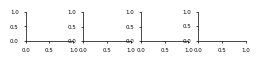

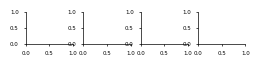

In [137]:
lo = fifi.FigureLayout('fig3_template.svg', autogenlayers=True, make_mplfigures=True, hide_layers=['Layer 1'])
lo.apply_mpl_methods() 
lo.clear_fflayer('mpl_layer') 

# Fig A

In [138]:
# set up figures
axs = np.empty(4, dtype=object)
axs[0] = lo.axes[('fig3A','A1')]
axs[1] = lo.axes[('fig3A','A2')]
axs[2] = lo.axes[('fig3A','A3')]
axs[3] = lo.axes[('fig3A','A4')]

In [139]:
# plot human controller H for the last trial of each update (i.e. 7 updates)
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
xlim = (0.1, 1.0)
xlim = (0.05, 1.0)
ylimphase = (-np.pi,0)
yticksphase = [-np.pi,0.]
yticklabelsphase = [r'$-\pi$',r'$0$']
trial_num = Hs.shape[2]
# update_trials = [0,4,9]
update_trials = [0,3,17]
update_trials = [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
trial = 17 # last adaptive trial
# avg baseline G
# Gs_base_mean = np.mean(Gs_base[sub],axis=0)
# fig,axs = plt.subplots(1,4,sharex=True,sharey=True,figsize=(5,1.5),dpi=300)

for cond, condition in enumerate(condition_orders):
    # mean across 3 trials 
    I_last_3_trials = np.mean(np.abs(Gs[:,cond,15:18,:]),axis = 1) # last 3 adaptive trials 
    I_first_3_trials = np.mean(np.abs(Gs[:,cond,3:6,:]),axis = 1) # first 3 adaptive trials
    selected = np.concatenate((Gs[:,cond,:3], Gs[:,cond,-3:]), axis=1) # 6 fixed trials
    I_star = np.mean(np.abs(selected),axis = 1) # I*

    ax = axs[cond+1]
    # mean across subjects
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(I_star, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'black',edgecolor='none')
    ax.set_title(str(condition)+'-order\ninterface')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(I_last_3_trials, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'blue',label = 'final (co-adapted)')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'blue',edgecolor='none')
    # mean, quantile25, quantile50, quantile75 = mean_and_interquartile(I_first_3_trials, axis = 0)
    # ax.plot(freqs,quantile50,'-',marker = '.',color = 'pink',label = 'initial',linestyle='-')
    # ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'pink',edgecolor='none')

    # stats test for each frequency
    for f in range(len(freqs)):
        data1 = I_last_3_trials[:,f] # average across trials
        data2 = I_star[:,f] # average across trials
        statistic, p_value = stats.ttest_rel(data1, data2)
        # print(f"  p-value: {p_value}")
        print(f" {freqs[f]:.3f}, p-value: {p_value:.3f}") # print first 3 decimals

        # if p_value < 0.05, display * on the plot at y = 0.9 for the corresponding frequency
        if p_value < 0.05:
            if cond == 0:
                where_star = 1
            else:
                where_star = 3
            ax.text(freqs[f], where_star, '*', ha='center', va='center',fontweight='bold')  

    print('\n')


ax = axs[0]
# mean across 3 trials 
# H_base_last_3_trials = np.mean(Hs_base[:,-3:,:][:,:,IX],axis = 1) # last 3 fixed trials 
# H_base_first_3_trials = np.mean(Hs_base[:,:3,:][:,:,IX],axis = 1) # first 3 fixed trials
I_base_trials = np.mean(np.abs(Gs_base),axis = 1) # first 3 fixed trials
# mean across subjects
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(I_base_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'black')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'black',edgecolor='none')
ax.set_title('passthrough\n'+r'$I = 1$')

for j in range(4):
    ax = axs[j]
    # ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks,rotation=90, fontsize=MINI_SIZE) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.set_ylim(0.6,5.5)
    # ax.tick_params(direction="in")

yticks_shared = [0.6, 1, 2, 3, 5]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.6, 1, 2, 3, 5])
axs[0].set_ylabel(r'interface $||I||$')

# Match tick positions to A1 but hide labels (log scale can redraw labels if ticks are cleared)
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)
axs[0].tick_params(axis='y', which='minor', labelleft=False)
axs[-1].legend( bbox_to_anchor=(1.05, 1) , borderaxespad=0.,frameon = False)
# plt.tight_layout()
# plt.show()

 0.100, p-value: 0.000
 0.150, p-value: 0.000
 0.250, p-value: 0.000
 0.350, p-value: 0.000
 0.550, p-value: 0.000
 0.650, p-value: 0.000
 0.850, p-value: 0.000
 0.950, p-value: 0.000


 0.100, p-value: 0.000
 0.150, p-value: 0.000
 0.250, p-value: 0.001
 0.350, p-value: 0.001
 0.550, p-value: 0.003
 0.650, p-value: 0.004
 0.850, p-value: 0.005
 0.950, p-value: 0.005


 0.100, p-value: 0.005
 0.150, p-value: 0.002
 0.250, p-value: 0.004
 0.350, p-value: 0.003
 0.550, p-value: 0.003
 0.650, p-value: 0.003
 0.850, p-value: 0.003
 0.950, p-value: 0.003




/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_36812/1820170189.py:27: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')


# Fig B

In [140]:
# set up figures
axs = np.empty(4, dtype=object)
axs[0] = lo.axes[('fig3B','B1')]
axs[1] = lo.axes[('fig3B','B2')]
axs[2] = lo.axes[('fig3B','B3')]
axs[3] = lo.axes[('fig3B','B4')]

In [141]:
# plot human controller H for the last trial of each update (i.e. 7 updates)
xticks = np.array([0.1 , 0.15, 0.25, 0.35, 0.55, 0.65, 0.85, 0.95])
xlim = (0.1, 1.0)
xlim = (0.05, 1.0)
ylimphase = (-np.pi,0)
yticksphase = [-np.pi,0.]
yticklabelsphase = [r'$-\pi$',r'$0$']
trial_num = Hs.shape[2]
# update_trials = [0,4,9]
update_trials = [0,3,17]
update_trials = [3,4,5,6,7,8,9,10,11,12,13,14,15,16,17]
trial = 17 # last adaptive trial
# avg baseline G
# Gs_base_mean = np.mean(Gs_base[sub],axis=0)
# fig,axs = plt.subplots(1,4,sharex=True,sharey=True,figsize=(5,1.2),dpi=300)

for cond, condition in enumerate(condition_orders):
    # mean across 3 trials 
    H_last_3_trials = np.mean(np.abs(Hs[:,cond,15:18,:][:,:,IX]),axis = 1) # last 3 adaptive trials 
    H_first_3_trials = np.mean(np.abs(Hs[:,cond,3:6,:][:,:,IX]),axis = 1) # first 3 adaptive trials
    # H_last_trials = np.abs(Hs[:,cond,17,IX]) # last adaptive trials 
    # H_first_trials = np.abs(Hs[:,cond,3,IX]) # first adaptive trials
    selected = np.concatenate((Hs[:,cond,:3][:,:,IX], Hs[:,cond,-3:][:,:,IX]), axis=1) # 6 fixed trials
    H_I_star = np.mean(np.abs(selected),axis = 1) # I*

    ax = axs[cond+1]
    # mean across subjects
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_I_star, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'black',edgecolor='none')
    # ax.set_title(str(condition)+'-order\nInterface')
    mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_last_3_trials, axis = 0)
    ax.plot(freqs,quantile50,'-',marker = '.',color = 'red', label = 'final (co-adapted)')
    ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'red',edgecolor='none')
    # mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_first_3_trials, axis = 0)
    # ax.plot(freqs,quantile50,'-',marker = '.',color = 'pink',label = 'initial',linestyle='-')
    # ax.fill_between(freqs,quantile25,quantile75,alpha = 0.2,color = 'pink',edgecolor='none')

    # stats test for each frequency
    for f in range(len(freqs)):
        data1 = H_last_3_trials[:,f] # average across trials
        data2 = H_I_star[:,f] # average across trials
        statistic, p_value = stats.ttest_rel(data1, data2)
        # print(f"  p-value: {p_value}")
        print(f" {freqs[f]:.3f}, p-value: {p_value:.3f}") # print first 3 decimals

        # if p_value < 0.05, display * on the plot at y = 0.9 for the corresponding frequency
        if p_value < 0.05:
            ax.text(freqs[f], 0.9, '*', ha='center', va='center',  fontweight='bold')  

    print('\n')


ax = axs[0]
# mean across 3 trials 
# H_base_last_3_trials = np.mean(Hs_base[:,-3:,:][:,:,IX],axis = 1) # last 3 fixed trials 
# H_base_first_3_trials = np.mean(Hs_base[:,:3,:][:,:,IX],axis = 1) # first 3 fixed trials
H_base_trials = np.mean(np.abs(Hs_base[:,:,IX]),axis = 1) # first 3 fixed trials
# mean across subjects
mean, quantile25, quantile50, quantile75 = mean_and_interquartile(H_base_trials, axis = 0)
ax.plot(freqs,quantile50,'-',marker = '.',color = 'white')
ax.fill_between(freqs,quantile25,quantile75,alpha = 0.8,color = 'black',edgecolor='none')
# ax.set_title('passthrough')

for j in range(4):
    ax = axs[j]
    # ax.set_xscale("log")
    # ax.set_yscale("log")
    ax.set_xlim(xlim)
    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks,rotation=90, fontsize=MINI_SIZE) 
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid('on',axis='x',zorder=-1,alpha = 0.3)
    ax.set_ylim(0.15,1)
    ax.set_xlabel('frequency (Hz)')
    # ax.tick_params(direction="in")

yticks_shared = [0.5,1.0]
axs[0].set_yticks(yticks_shared)
axs[0].set_yticklabels([0.5,1.0])
axs[0].set_ylabel(r'human $||H||$')
for idx in (1, 2, 3):
    axs[idx].set_yticks(yticks_shared)
    axs[idx].tick_params(axis='y', which='both', labelleft=False)


axs[-1].legend(bbox_to_anchor=(1.05, 1), borderaxespad=0.,frameon = False)
# axs[-1].legend(loc='lower right', borderaxespad=0.,frameon = False)
# plt.tight_layout()
# plt.show()

 0.100, p-value: 0.000
 0.150, p-value: 0.000
 0.250, p-value: 0.000
 0.350, p-value: 0.000
 0.550, p-value: 0.000
 0.650, p-value: 0.027
 0.850, p-value: 0.027
 0.950, p-value: 0.153


 0.100, p-value: 0.004
 0.150, p-value: 0.054
 0.250, p-value: 0.009
 0.350, p-value: 0.003
 0.550, p-value: 0.003
 0.650, p-value: 0.131
 0.850, p-value: 0.144
 0.950, p-value: 0.394


 0.100, p-value: 0.028
 0.150, p-value: 0.010
 0.250, p-value: 0.328
 0.350, p-value: 0.016
 0.550, p-value: 0.015
 0.650, p-value: 0.046
 0.850, p-value: 0.127
 0.950, p-value: 0.221




/var/folders/p2/rhv64v0d7sd4cvv1wvcg9v700000gn/T/ipykernel_36812/3015951840.py:29: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  ax.plot(freqs,quantile50,'-',marker = '.',color = 'black',label = 'baseline (fixed)',linestyle='--')


# write to figure layout

In [142]:
lo.append_figure_to_layer(lo.figures['fig3A'], 'A1', cleartarget=True)
lo.append_figure_to_layer(lo.figures['fig3B'], 'B1', cleartarget=True)

lo.write_svg('fig3_template.svg')
display(SVG('fig3_template.svg'))